# HMM Regimes and Five-Day Forward Realised-Volatility Forecasting

Structure:

1. Load NIFTY 50 prices.
2. Calculate daily returns.
3. Estimate a two-state lognormal HMM.
4. Identify low- and high-volatility regimes.
5. Train one random forest in each regime.
6. Forecast volatility over the **next five trading days**.
7. Compare out-of-sample RMSE with simple benchmarks.


Here, the target is five-day **forward realised volatility**:

$$
RV^{(5)}_{t+1:t+5}
=
100\sqrt{
\frac{252}{5}
\sum_{i=1}^{5}r_{t+i}^{2}
}.
$$

At time \(t\), none of the five returns in this target has occurred yet.
Therefore, this is a genuine forward volatility forecast.

The HMM is fitted to exponentially weighted volatility rather than a fixed
rolling window. This gives more weight to recent returns and reacts more
quickly when market conditions change.

In [1]:
from datetime import datetime
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import yfinance as yf
except ModuleNotFoundError:
    yf = None

from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 1. Load the NIFTY 50 prices

In [2]:
TICKER = "^NSEI"
START_DATE = datetime(2006, 1, 1)
END_DATE = datetime(2023, 5, 1)

# Keep nifty50_prices.csv in the same folder as this notebook.
PRICE_FILE = Path("nifty50_prices.csv")

if PRICE_FILE.exists():
    print(f"Loading local data from {PRICE_FILE}")
    prices = pd.read_csv(
        PRICE_FILE,
        parse_dates=["Date"],
        index_col="Date",
    )
else:
    if yf is None:
        raise ModuleNotFoundError(
            "nifty50_prices.csv was not found and yfinance is not installed. "
            "Place the CSV beside the notebook or install yfinance."
        )

    print("Local CSV not found. Downloading data from Yahoo Finance...")

    downloaded = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
    )

    if downloaded.empty:
        raise RuntimeError(
            "No price data were available. "
            "Check the internet connection or CSV path."
        )

    if isinstance(downloaded.columns, pd.MultiIndex):
        first_level = downloaded.columns.get_level_values(0)
        price_column = (
            "Adj Close" if "Adj Close" in first_level else "Close"
        )
        price = downloaded[price_column]

        if isinstance(price, pd.DataFrame):
            price = price.iloc[:, 0]
    else:
        price_column = (
            "Adj Close"
            if "Adj Close" in downloaded.columns
            else "Close"
        )
        price = downloaded[price_column]

    prices = pd.DataFrame(
        {"Price": pd.to_numeric(price, errors="coerce")}
    ).dropna()

    prices.index.name = "Date"
    prices.to_csv(PRICE_FILE)

# Standardise the column name.
if "Price" not in prices.columns:
    possible_columns = [
        column
        for column in prices.columns
        if column.lower() in {"price", "close", "adj close"}
    ]

    if not possible_columns:
        raise ValueError(
            "The CSV must contain a Price, Close or Adj Close column."
        )

    prices = prices.rename(
        columns={possible_columns[0]: "Price"}
    )

prices = prices[["Price"]].dropna().sort_index()

print(f"Price observations: {len(prices):,}")
prices.head()

Loading local data from nifty50_prices.csv
Price observations: 3,826


,Price
Date,
2007-09-17,"4,494.649902"
2007-09-18,"4,546.200195"
2007-09-19,"4,732.350098"
2007-09-20,"4,747.549805"
2007-09-21,"4,837.549805"


## 2. Construct returns and volatility variables

In [3]:
data = prices.copy()

# Daily log return.
data["Return"] = np.log(
    data["Price"] / data["Price"].shift(1)
)
data["Return (%)"] = 100.0 * data["Return"]
data["Absolute Return (%)"] = data["Return (%)"].abs()

# Historical realised volatility over the previous 5 and 20 days.
# Both are annualised and expressed in percentage points.
for window in [5, 20]:
    data[f"Historical RV {window}D (%)"] = (
        np.sqrt(
            252.0
            * data["Return"]
            .pow(2)
            .rolling(window)
            .mean()
        )
        * 100.0
    )

# RiskMetrics-style exponentially weighted variance.
# lambda = 0.94 gives more weight to recent observations.
EWMA_LAMBDA = 0.94

returns = data["Return"].to_numpy()
ewma_variance = np.full(len(data), np.nan)

valid_start = np.where(np.isfinite(returns))[0][0]
initial_end = valid_start + 20

ewma_variance[initial_end] = np.nanmean(
    returns[valid_start:initial_end + 1] ** 2
)

for time in range(initial_end + 1, len(data)):
    ewma_variance[time] = (
        EWMA_LAMBDA * ewma_variance[time - 1]
        + (1.0 - EWMA_LAMBDA) * returns[time] ** 2
    )

data["EWMA Volatility (%)"] = (
    np.sqrt(252.0 * ewma_variance) * 100.0
)

# Genuine forward target: realised volatility during the next five days.
FORECAST_HORIZON = 5

future_squared_returns = sum(
    data["Return"].shift(-step).pow(2)
    for step in range(1, FORECAST_HORIZON + 1)
)

data["Forward RV 5D (%)"] = (
    np.sqrt(
        (252.0 / FORECAST_HORIZON)
        * future_squared_returns
    )
    * 100.0
)

data.dropna(inplace=True)
data["Position"] = np.arange(len(data))

print(f"Usable observations: {len(data):,}")
print(f"Start date: {data.index.min().date()}")
print(f"End date: {data.index.max().date()}")

data.head()

Usable observations: 3,800
Start date: 2007-10-17
End date: 2023-04-21


,Price,Return,Return (%),Absolute Return (%),Historical RV 5D (%),Historical RV 20D (%),EWMA Volatility (%),Forward RV 5D (%),Position
Date,,,,,,,,,
2007-10-17,"5,559.299805",-0.019373,-1.937294,1.937294,37.717817,34.057697,33.470856,50.838768,0
2007-10-18,"5,351.000000",-0.038189,-3.818871,3.818871,45.177988,33.775258,35.687350,44.009396,1
2007-10-19,"5,215.299805",-0.025687,-2.568688,2.568688,47.082699,34.965829,36.012997,43.433724,2
2007-10-22,"5,184.000000",-0.006020,-0.601962,0.601962,35.708200,34.390952,34.994266,49.885181,3
2007-10-23,"5,473.700195",0.054378,5.437788,5.437788,52.586061,38.833049,39.977671,31.910733,4


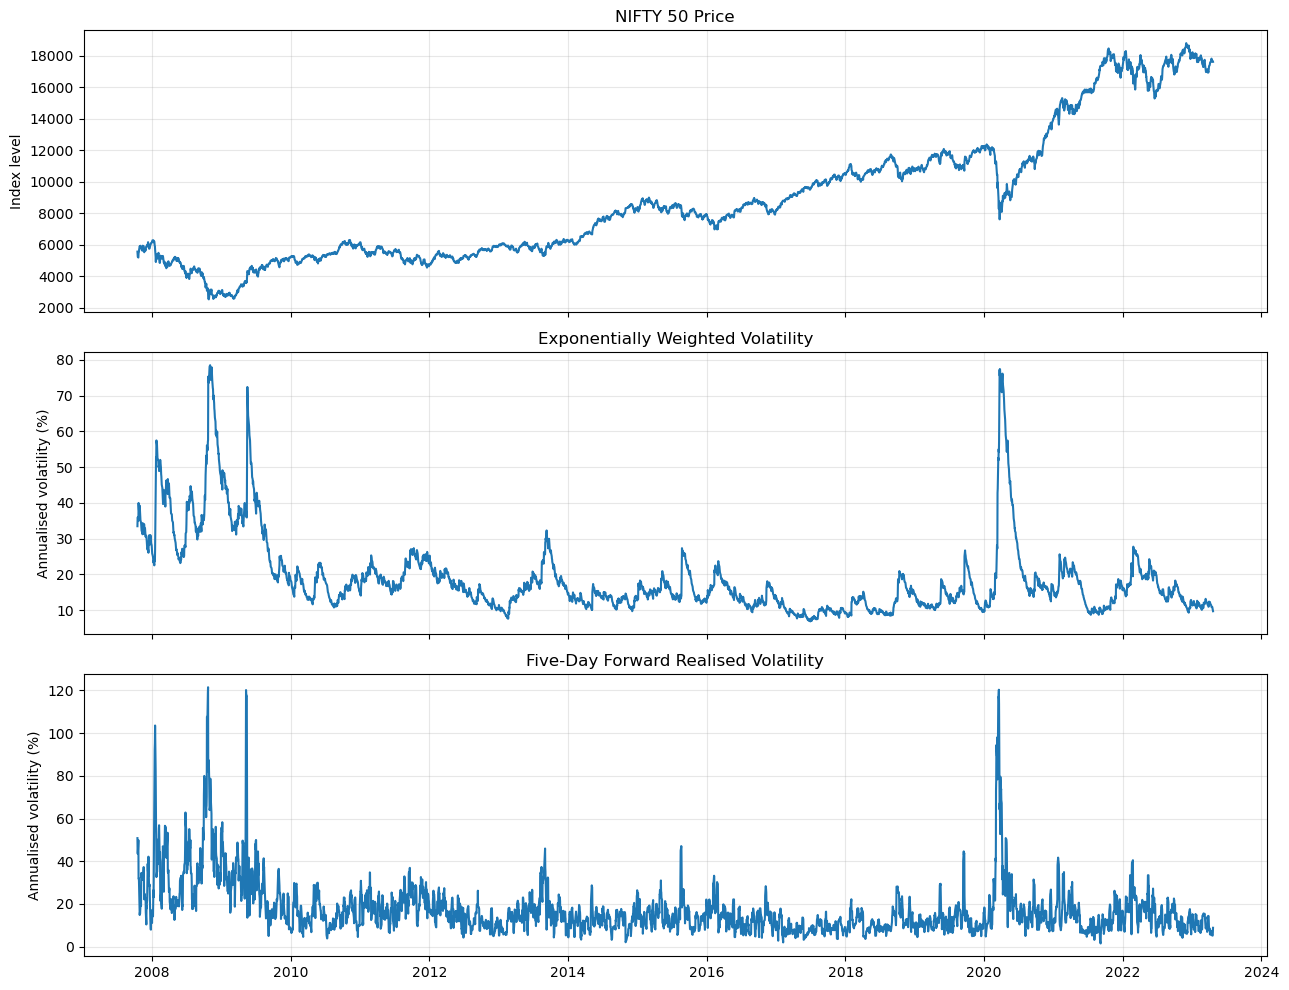

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(data.index, data["Price"])
axes[0].set_title("NIFTY 50 Price")
axes[0].set_ylabel("Index level")
axes[0].grid(alpha=0.3)

axes[1].plot(data.index, data["EWMA Volatility (%)"])
axes[1].set_title("Exponentially Weighted Volatility")
axes[1].set_ylabel("Annualised volatility (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(data.index, data["Forward RV 5D (%)"])
axes[2].set_title("Five-Day Forward Realised Volatility")
axes[2].set_ylabel("Annualised volatility (%)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Lognormal HMM implemented from scratch

The regime indicator is the positive EWMA volatility series.

For state \(j\),

$$
\log \sigma_t^{EWMA}
\mid z_t=j
\sim \mathcal{N}(\mu_j,s_j^2).
$$

Therefore, EWMA volatility is lognormally distributed within each regime.
State 0 is ordered as the low-volatility state and state 1 as the
high-volatility state.

In [5]:
class LognormalHMM:
    """Simple two-state HMM for positive volatility observations."""

    def __init__(
        self,
        num_states=2,
        max_iterations=100,
        tolerance=1e-6,
        random_state=42,
    ):
        self.num_states = num_states
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.random_state = random_state

    @staticmethod
    def _log_transform(observations):
        observations = np.asarray(
            observations,
            dtype=float,
        ).reshape(-1)

        if np.any(observations <= 0):
            raise ValueError(
                "All HMM observations must be strictly positive."
            )

        return np.log(observations)

    def _initialise(self, observations):
        log_observations = self._log_transform(observations)

        kmeans = KMeans(
            n_clusters=self.num_states,
            n_init=20,
            random_state=self.random_state,
        )

        labels = kmeans.fit_predict(
            log_observations.reshape(-1, 1)
        )

        self.log_means = np.array(
            [
                log_observations[labels == state].mean()
                for state in range(self.num_states)
            ]
        )

        self.log_stds = np.array(
            [
                max(
                    log_observations[labels == state].std(ddof=0),
                    1e-4,
                )
                for state in range(self.num_states)
            ]
        )

        self.initial_probabilities = np.full(
            self.num_states,
            1.0 / self.num_states,
        )

        # Persistent starting transition matrix.
        stay_probability = 0.95
        switch_probability = (
            1.0 - stay_probability
        ) / (self.num_states - 1)

        self.transition_matrix = np.full(
            (self.num_states, self.num_states),
            switch_probability,
        )
        np.fill_diagonal(
            self.transition_matrix,
            stay_probability,
        )

    def _emission_matrix(self, observations):
        log_observations = self._log_transform(observations)

        emissions = np.column_stack(
            [
                norm.pdf(
                    log_observations,
                    loc=self.log_means[state],
                    scale=self.log_stds[state],
                )
                for state in range(self.num_states)
            ]
        )

        return np.clip(emissions, 1e-300, None)

    def forward(self, observations):
        """Scaled forward algorithm."""
        emissions = self._emission_matrix(observations)
        n_observations = len(emissions)

        alpha = np.zeros(
            (n_observations, self.num_states)
        )
        scales = np.zeros(n_observations)

        alpha[0] = (
            self.initial_probabilities
            * emissions[0]
        )
        scales[0] = alpha[0].sum()
        alpha[0] /= scales[0]

        for time in range(1, n_observations):
            predicted_probabilities = (
                alpha[time - 1]
                @ self.transition_matrix
            )

            alpha[time] = (
                predicted_probabilities
                * emissions[time]
            )
            scales[time] = alpha[time].sum()
            alpha[time] /= scales[time]

        log_likelihood = np.log(scales).sum()

        return alpha, scales, log_likelihood

    def backward(self, observations, scales):
        """Scaled backward algorithm."""
        emissions = self._emission_matrix(observations)
        n_observations = len(emissions)

        beta = np.ones(
            (n_observations, self.num_states)
        )

        for time in range(
            n_observations - 2,
            -1,
            -1,
        ):
            beta[time] = (
                self.transition_matrix
                @ (
                    emissions[time + 1]
                    * beta[time + 1]
                )
            )
            beta[time] /= scales[time + 1]

        return beta

    def fit(self, observations):
        """Estimate all HMM parameters with Baum-Welch."""
        observations = np.asarray(
            observations,
            dtype=float,
        ).reshape(-1)

        log_observations = self._log_transform(
            observations
        )

        self._initialise(observations)
        self.log_likelihood_history = []

        for iteration in range(self.max_iterations):
            emissions = self._emission_matrix(
                observations
            )

            alpha, scales, log_likelihood = (
                self.forward(observations)
            )

            beta = self.backward(
                observations,
                scales,
            )

            self.log_likelihood_history.append(
                log_likelihood
            )

            gamma = alpha * beta
            gamma /= gamma.sum(
                axis=1,
                keepdims=True,
            )

            expected_transitions = np.zeros(
                (
                    self.num_states,
                    self.num_states,
                )
            )

            for time in range(len(observations) - 1):
                xi = (
                    alpha[time][:, None]
                    * self.transition_matrix
                    * (
                        emissions[time + 1]
                        * beta[time + 1]
                    )[None, :]
                )

                xi /= xi.sum()
                expected_transitions += xi

            self.initial_probabilities = gamma[0]
            self.initial_probabilities /= (
                self.initial_probabilities.sum()
            )

            self.transition_matrix = (
                expected_transitions + 1e-10
            )
            self.transition_matrix /= (
                self.transition_matrix.sum(
                    axis=1,
                    keepdims=True,
                )
            )

            state_weights = gamma.sum(axis=0)

            self.log_means = (
                gamma * log_observations[:, None]
            ).sum(axis=0) / state_weights

            log_variances = (
                gamma
                * (
                    log_observations[:, None]
                    - self.log_means[None, :]
                ) ** 2
            ).sum(axis=0) / state_weights

            self.log_stds = np.sqrt(
                np.maximum(log_variances, 1e-8)
            )

            if iteration > 0:
                likelihood_change = abs(
                    self.log_likelihood_history[-1]
                    - self.log_likelihood_history[-2]
                )

                if likelihood_change < self.tolerance:
                    break

        self._sort_states()
        return self

    def _sort_states(self):
        conditional_means = np.exp(
            self.log_means
            + 0.5 * self.log_stds**2
        )

        order = np.argsort(conditional_means)

        self.initial_probabilities = (
            self.initial_probabilities[order]
        )
        self.transition_matrix = (
            self.transition_matrix[
                np.ix_(order, order)
            ]
        )
        self.log_means = self.log_means[order]
        self.log_stds = self.log_stds[order]

    def mean_volatility(self):
        return np.exp(
            self.log_means
            + 0.5 * self.log_stds**2
        )

    def filtered_probabilities(self, observations):
        """Causal probabilities using observations up to each date."""
        alpha, _, _ = self.forward(observations)
        return alpha

## 4. Chronological split and HMM regime classification

In [6]:
TRAIN_FRACTION = 0.70
split_position = int(
    TRAIN_FRACTION * len(data)
)
split_date = data.index[split_position]

hmm_training_data = (
    data["EWMA Volatility (%)"]
    .iloc[:split_position]
    .to_numpy()
)

hmm = LognormalHMM(
    num_states=2,
    max_iterations=100,
    tolerance=1e-6,
    random_state=RANDOM_STATE,
)

hmm.fit(hmm_training_data)

filtered_probabilities = (
    hmm.filtered_probabilities(
        data["EWMA Volatility (%)"].to_numpy()
    )
)

data["Low-State Probability"] = (
    filtered_probabilities[:, 0]
)
data["High-State Probability"] = (
    filtered_probabilities[:, 1]
)
data["State"] = np.argmax(
    filtered_probabilities,
    axis=1,
)

state_summary = pd.DataFrame(
    {
        "State": [0, 1],
        "Interpretation": [
            "Low volatility",
            "High volatility",
        ],
        "Mean EWMA volatility (%)": (
            hmm.mean_volatility()
        ),
        "Persistence": np.diag(
            hmm.transition_matrix
        ),
        "Expected duration (days)": (
            1.0
            / (
                1.0
                - np.clip(
                    np.diag(
                        hmm.transition_matrix
                    ),
                    0.0,
                    1.0 - 1e-12,
                )
            )
        ),
    }
)

display(state_summary)

print("Transition matrix")
display(
    pd.DataFrame(
        hmm.transition_matrix,
        index=["From low", "From high"],
        columns=["To low", "To high"],
    )
)

,State,Interpretation,Mean EWMA volatility (%),Persistence,Expected duration (days)
0,0,Low volatility,13.542526,0.995944,246.566400
1,1,High volatility,31.508527,0.990613,106.528534


Transition matrix


,To low,To high
From low,0.995944,0.004056
From high,0.009387,0.990613


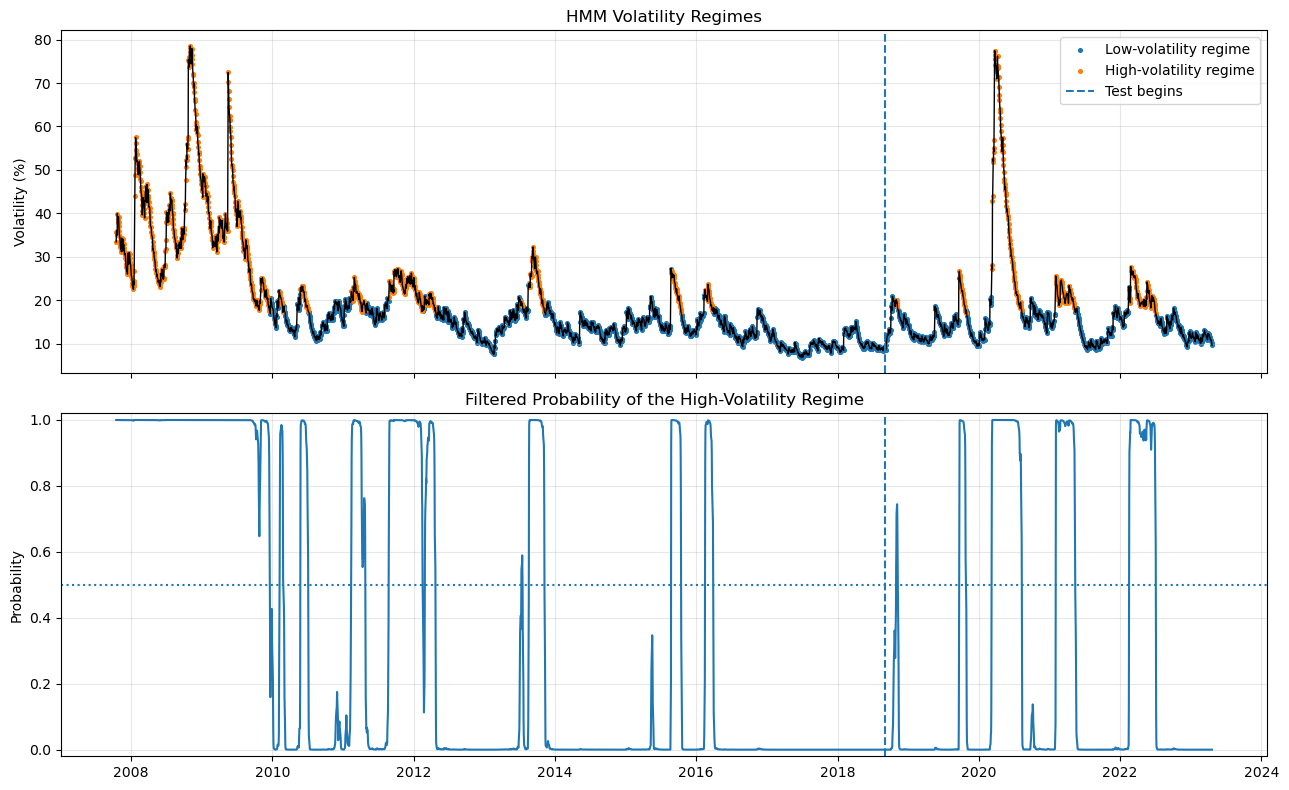

In [7]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 8),
    sharex=True,
)

axes[0].plot(
    data.index,
    data["EWMA Volatility (%)"],
    color="black",
    linewidth=1.0,
)

for state, label in [
    (0, "Low-volatility regime"),
    (1, "High-volatility regime"),
]:
    mask = data["State"] == state

    axes[0].scatter(
        data.index[mask],
        data.loc[
            mask,
            "EWMA Volatility (%)",
        ],
        s=7,
        label=label,
    )

axes[0].axvline(
    split_date,
    linestyle="--",
    label="Test begins",
)
axes[0].set_ylabel("Volatility (%)")
axes[0].set_title("HMM Volatility Regimes")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    data.index,
    data["High-State Probability"],
)
axes[1].axhline(0.5, linestyle=":")
axes[1].axvline(split_date, linestyle="--")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title(
    "Filtered Probability of the High-Volatility Regime"
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Forecasting data

The random forest uses four simple variables known at time \(t\):

- EWMA volatility;
- historical five-day realised volatility;
- historical 20-day realised volatility;
- today's absolute return.

The target uses returns $$(t+1,\ldots,t+5)$$.

A training row is included only when its complete five-day target ends before
the test period. This prevents leakage across the train/test boundary.

In [8]:
feature_columns = [
    "EWMA Volatility (%)",
    "Historical RV 5D (%)",
    "Historical RV 20D (%)",
    "Absolute Return (%)",
]

forecast_data = data[
    feature_columns
    + [
        "State",
        "Forward RV 5D (%)",
        "Position",
    ]
].copy()

forecast_data["Target End Position"] = (
    forecast_data["Position"]
    + FORECAST_HORIZON
)

forecast_data.dropna(inplace=True)

training_rows = (
    forecast_data["Target End Position"]
    < split_position
)

test_rows = (
    forecast_data["Position"]
    >= split_position
)

train_forecasts = forecast_data.loc[
    training_rows
].copy()

test_forecasts = forecast_data.loc[
    test_rows
].copy()

print(f"Training forecast rows: {len(train_forecasts):,}")
print(f"Test forecast rows: {len(test_forecasts):,}")
print(f"Test begins: {split_date.date()}")

Training forecast rows: 2,655
Test forecast rows: 1,140
Test begins: 2018-09-03


## 6. Train the random-forest models

In [9]:
def train_regime_random_forests(
    training_data,
    features,
):
    """Train one random forest for each HMM state."""
    models = {}

    for state in [0, 1]:
        state_data = training_data[
            training_data["State"] == state
        ]

        print(
            f"State {state} training observations: "
            f"{len(state_data):,}"
        )

        model = RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=3,
            max_features=0.60,
            random_state=RANDOM_STATE + state,
            n_jobs=-1,
        )

        model.fit(
            state_data[features],
            state_data["Forward RV 5D (%)"],
        )

        models[state] = model

    return models


def predict_with_regime_models(
    models,
    evaluation_data,
    features,
):
    """Select the appropriate RF using today's HMM state."""
    predictions = np.empty(
        len(evaluation_data)
    )

    for state in [0, 1]:
        state_mask = (
            evaluation_data["State"]
            .to_numpy()
            == state
        )

        predictions[state_mask] = (
            models[state].predict(
                evaluation_data.loc[
                    state_mask,
                    features,
                ]
            )
        )

    return predictions


regime_models = train_regime_random_forests(
    train_forecasts,
    feature_columns,
)

test_forecasts["HMM + RF"] = (
    predict_with_regime_models(
        regime_models,
        test_forecasts,
        feature_columns,
    )
)

# A global RF is included as a useful sanity check.
global_rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    max_features=0.60,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

global_rf.fit(
    train_forecasts[feature_columns],
    train_forecasts["Forward RV 5D (%)"],
)

test_forecasts["Global RF"] = (
    global_rf.predict(
        test_forecasts[feature_columns]
    )
)

# Same-horizon historical benchmark:
# use volatility over the previous five days as the next-five-day forecast.
test_forecasts["Historical 5D Benchmark"] = (
    test_forecasts["Historical RV 5D (%)"]
)

# EWMA benchmark.
test_forecasts["EWMA Benchmark"] = (
    test_forecasts["EWMA Volatility (%)"]
)

State 0 training observations: 1,763
State 1 training observations: 892


## 7. Out-of-sample results

In [10]:
actual = test_forecasts[
    "Forward RV 5D (%)"
].to_numpy()


def calculate_metrics(
    actual_values,
    predicted_values,
):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(
                actual_values,
                predicted_values,
            )
        ),
        "MAE": mean_absolute_error(
            actual_values,
            predicted_values,
        ),
        "R2": r2_score(
            actual_values,
            predicted_values,
        ),
    }


prediction_columns = [
    "HMM + RF",
    "Global RF",
    "Historical 5D Benchmark",
    "EWMA Benchmark",
]

result_rows = []

for model_name in prediction_columns:
    result_rows.append(
        {
            "Model": model_name,
            **calculate_metrics(
                actual,
                test_forecasts[
                    model_name
                ].to_numpy(),
            ),
        }
    )

results = pd.DataFrame(
    result_rows
).sort_values("RMSE")

historical_rmse = results.loc[
    results["Model"]
    == "Historical 5D Benchmark",
    "RMSE",
].iloc[0]

results[
    "RMSE improvement vs historical benchmark (%)"
] = (
    100.0
    * (
        historical_rmse
        - results["RMSE"]
    )
    / historical_rmse
)

display(results)

,Model,RMSE,MAE,R2,RMSE improvement vs historical benchmark (%)
0,HMM + RF,9.256980,5.913607,0.431777,11.690905
1,Global RF,9.278388,5.916571,0.429146,11.486672
3,EWMA Benchmark,10.475808,6.523043,0.272295,0.063609
2,Historical 5D Benchmark,10.482476,6.973106,0.271368,0.000000


In [11]:
regime_result_rows = []

for state, regime_name in [
    (0, "Low volatility"),
    (1, "High volatility"),
]:
    subset = test_forecasts[
        test_forecasts["State"] == state
    ]

    for model_name in [
        "HMM + RF",
        "Historical 5D Benchmark",
    ]:
        regime_result_rows.append(
            {
                "Regime": regime_name,
                "Model": model_name,
                "Observations": len(subset),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        subset[
                            "Forward RV 5D (%)"
                        ],
                        subset[model_name],
                    )
                ),
            }
        )

regime_results = pd.DataFrame(
    regime_result_rows
)

display(
    regime_results.pivot(
        index="Model",
        columns="Regime",
        values="RMSE",
    )
)

Regime,High volatility,Low volatility
Model,,
HMM + RF,13.356768,7.332626
Historical 5D Benchmark,15.566900,8.017224


## 8. Non-overlapping weekly check

Daily five-day targets overlap with one another. For example, forecasts made
on consecutive days share four future returns.

The main table uses every available forecast origin. The table below repeats
the evaluation using every fifth test observation, so the evaluated target
windows do not overlap.

In [12]:
non_overlapping = test_forecasts.iloc[
    ::FORECAST_HORIZON
].copy()

non_overlapping_actual = (
    non_overlapping[
        "Forward RV 5D (%)"
    ].to_numpy()
)

non_overlapping_rows = []

for model_name in prediction_columns:
    metrics = calculate_metrics(
        non_overlapping_actual,
        non_overlapping[
            model_name
        ].to_numpy(),
    )

    non_overlapping_rows.append(
        {
            "Model": model_name,
            "Observations": len(
                non_overlapping
            ),
            **metrics,
        }
    )

non_overlapping_results = pd.DataFrame(
    non_overlapping_rows
).sort_values("RMSE")

display(non_overlapping_results)

,Model,Observations,RMSE,MAE,R2
1,Global RF,228,8.605904,5.823791,0.502929
0,HMM + RF,228,8.613099,5.794434,0.502097
2,Historical 5D Benchmark,228,9.462943,6.714073,0.398995
3,EWMA Benchmark,228,10.172089,6.477057,0.305542


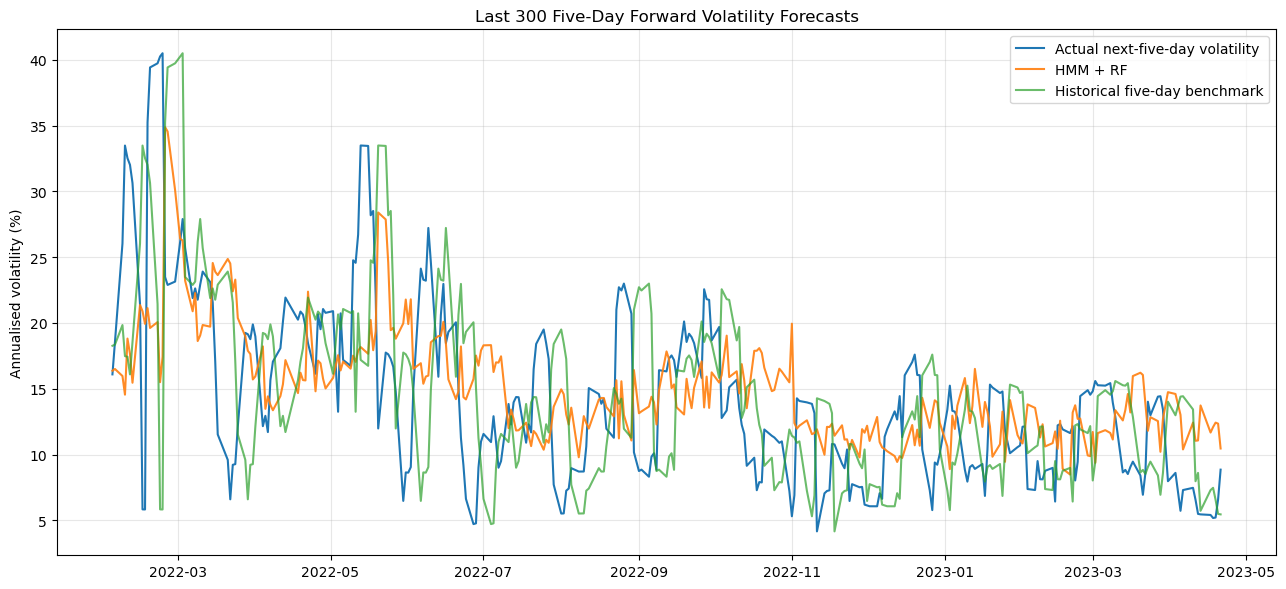

In [13]:
plot_rows = min(
    300,
    len(test_forecasts),
)

plot_data = test_forecasts.iloc[
    -plot_rows:
]

plt.figure(figsize=(13, 6))

plt.plot(
    plot_data.index,
    plot_data["Forward RV 5D (%)"],
    label="Actual next-five-day volatility",
    linewidth=1.5,
)

plt.plot(
    plot_data.index,
    plot_data["HMM + RF"],
    label="HMM + RF",
    alpha=0.9,
)

plt.plot(
    plot_data.index,
    plot_data[
        "Historical 5D Benchmark"
    ],
    label="Historical five-day benchmark",
    alpha=0.7,
)

plt.title(
    f"Last {plot_rows} Five-Day Forward Volatility Forecasts"
)
plt.ylabel("Annualised volatility (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature importance

,Regime,Feature,Importance
4,High volatility,EWMA Volatility (%),0.331479
5,High volatility,Historical RV 5D (%),0.304893
6,High volatility,Historical RV 20D (%),0.272626
7,High volatility,Absolute Return (%),0.091002
2,Low volatility,Historical RV 20D (%),0.330703
0,Low volatility,EWMA Volatility (%),0.301481
1,Low volatility,Historical RV 5D (%),0.205642
3,Low volatility,Absolute Return (%),0.162174


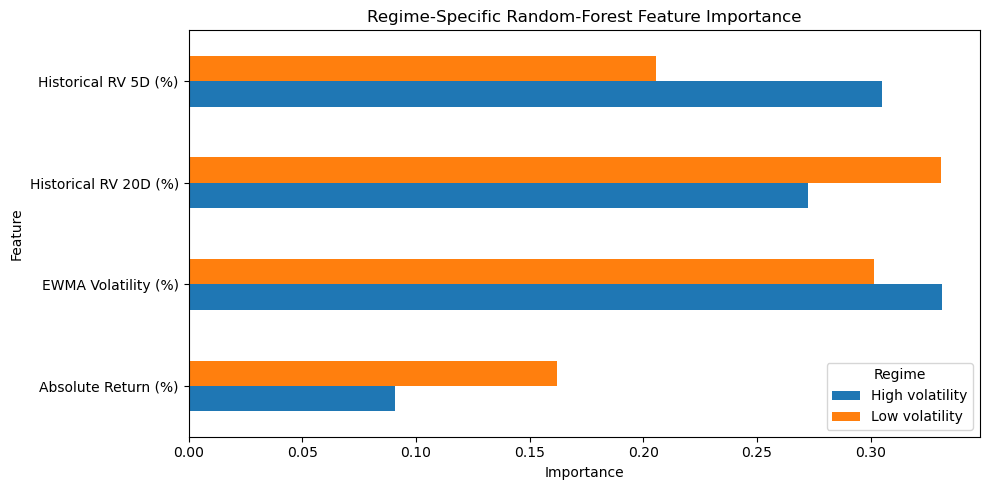

In [14]:
feature_importance_rows = []

for state, regime_name in [
    (0, "Low volatility"),
    (1, "High volatility"),
]:
    model = regime_models[state]

    for feature, importance in zip(
        feature_columns,
        model.feature_importances_,
    ):
        feature_importance_rows.append(
            {
                "Regime": regime_name,
                "Feature": feature,
                "Importance": importance,
            }
        )

feature_importance = pd.DataFrame(
    feature_importance_rows
)

display(
    feature_importance.sort_values(
        ["Regime", "Importance"],
        ascending=[True, False],
    )
)

feature_importance.pivot(
    index="Feature",
    columns="Regime",
    values="Importance",
).plot(
    kind="barh",
    figsize=(10, 5),
)

plt.title(
    "Regime-Specific Random-Forest Feature Importance"
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Correctness checks and saved results

In [15]:
assert np.allclose(
    hmm.transition_matrix.sum(axis=1),
    1.0,
)

assert np.allclose(
    filtered_probabilities.sum(axis=1),
    1.0,
)

assert (
    train_forecasts[
        "Target End Position"
    ].max()
    < split_position
)

assert (
    test_forecasts["Position"].min()
    >= split_position
)

assert np.isfinite(
    test_forecasts["HMM + RF"]
).all()

print("All correctness and leakage checks passed.")

All correctness and leakage checks passed.


In [16]:
OUTPUT_DIRECTORY = Path(
    "outputs_forward_5day_volatility"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

state_summary.to_csv(
    OUTPUT_DIRECTORY
    / "hmm_state_summary.csv",
    index=False,
)

results.to_csv(
    OUTPUT_DIRECTORY
    / "forecast_results.csv",
    index=False,
)

regime_results.to_csv(
    OUTPUT_DIRECTORY
    / "regime_results.csv",
    index=False,
)

non_overlapping_results.to_csv(
    OUTPUT_DIRECTORY
    / "non_overlapping_results.csv",
    index=False,
)

feature_importance.to_csv(
    OUTPUT_DIRECTORY
    / "feature_importance.csv",
    index=False,
)

test_forecasts[
    [
        "State",
        "Forward RV 5D (%)",
        "HMM + RF",
        "Global RF",
        "Historical 5D Benchmark",
        "EWMA Benchmark",
    ]
].to_csv(
    OUTPUT_DIRECTORY
    / "test_predictions.csv"
)

print(
    "Results saved to:",
    OUTPUT_DIRECTORY.resolve(),
)

Results saved to: C:\Users\Me\OneDrive\Desktop\hmm_volatility_project\outputs_forward_5day_volatility


## Final interpretation

This version predicts:

> the annualised volatility actually realised over the next trading week.

The historical five-day benchmark asks whether next week's volatility will
equal the volatility observed during the previous week.

The HMM + RF model is useful only if it reduces out-of-sample RMSE relative
to that benchmark. The global RF is included to show whether splitting the
data into HMM regimes adds value beyond an ordinary random forest.